**READ ME**

In this project Bacterial Pollution Samples and Rainfall Data is used to illustrate bacterial pollution trends along the River Nidd and how it is influenced by rainfall and distance travelled along the river. Also includes the creation of an intuitive, interactive map which could be used to communicate bacterial pollution levels along the river nidd to the general public.

In [ ]:
# Import packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import folium
from folium.plugins import BeautifyIcon

In [ ]:
# Load Data
print("loading data...")
try:
    mst = pd.read_csv("mst_samples.csv")
    bact = pd.read_csv("bacteria_samples.csv")
except FileNotFoundError as e:
    print(f"error，cannot find files: {e}")
    exit()

# Clean MST Data
print("cleaning MST data...")

# Unify Site Names
site_mapping = {
    'Nidd @ Lido': 'Knaresborough Lido',
    'Nidd @ Hampsthwaite': 'Hampsthwaite',
    'Nidd @ Scotton Mill': 'Scotton Mill',
    'Nidd @ Summerbridge': 'Summerbridge',
    'Nidd @ Pateley Bridge': 'Pateley Bridge'
}
mst['Site_mapped'] = mst['Site'].map(site_mapping)

# Format date time
mst['Date_obj'] = pd.to_datetime(mst['Date'], format='%d/%m/%Y', errors='coerce')


def clean_marker(val):
    if pd.isna(val):
        return None
    val = str(val).strip()
    if val == '<2':
        return 1.9
    if val == 'N/F':
        return 0.0
    try:
        return float(val)
    except ValueError:
        return None

mst['Hubac_numeric'] = mst['Hubac'].apply(clean_marker)
mst['Rubac_numeric'] = mst['Rubac'].apply(clean_marker)

# Drop unnamed columns
mst_clean = mst[['Site_mapped', 'Date_obj', 'Hubac_numeric', 'Rubac_numeric', 'E. Coli', 'IE']].copy()

mst_clean.rename(columns={'E. Coli': 'mst_e_coli', 'IE': 'mst_ie'}, inplace=True)

# Convert bacterial data to preferred datatime format
print("cleaning bacteria data...")
bact['Date_obj'] = pd.to_datetime(bact['date'], format='%d/%m/%Y', errors='coerce')

# Merge all sites data into a single file
print("merging data...")
merged_all_sites = pd.merge(mst_clean, bact, left_on=['Site_mapped', 'Date_obj'], right_on=['site', 'Date_obj'], how='inner')

merged_all_sites = merged_all_sites.sort_values('date_time').drop_duplicates(subset=['Site_mapped', 'Date_obj'], keep='last')

merged_all_sites = merged_all_sites.sort_values(['Date_obj', 'Site_mapped'])

# Print
print(f"successful！all get {len(merged_all_sites)} date。")
print("every sites date：")
print(merged_all_sites['Site_mapped'].value_counts())

# Export merged database to CSV
output_filename = 'all_sites.csv'
merged_all_sites.to_csv(output_filename, index=False)
print(f"successful output '{output_filename}'")

loading data...
cleaning MST data...
cleaning bacteria data...
merging data...
successful！all get 36 date。
every sites date：
Site_mapped
Knaresborough Lido    13
Hampsthwaite           6
Scotton Mill           6
Summerbridge           6
Pateley Bridge         5
Name: count, dtype: int64
successful output 'all_sites.csv'


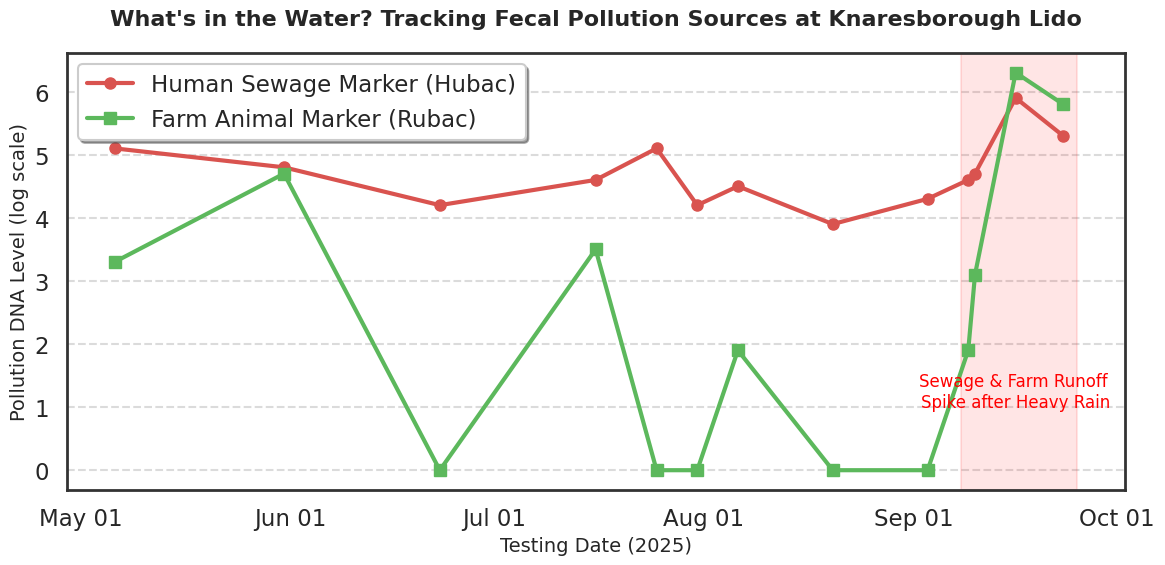

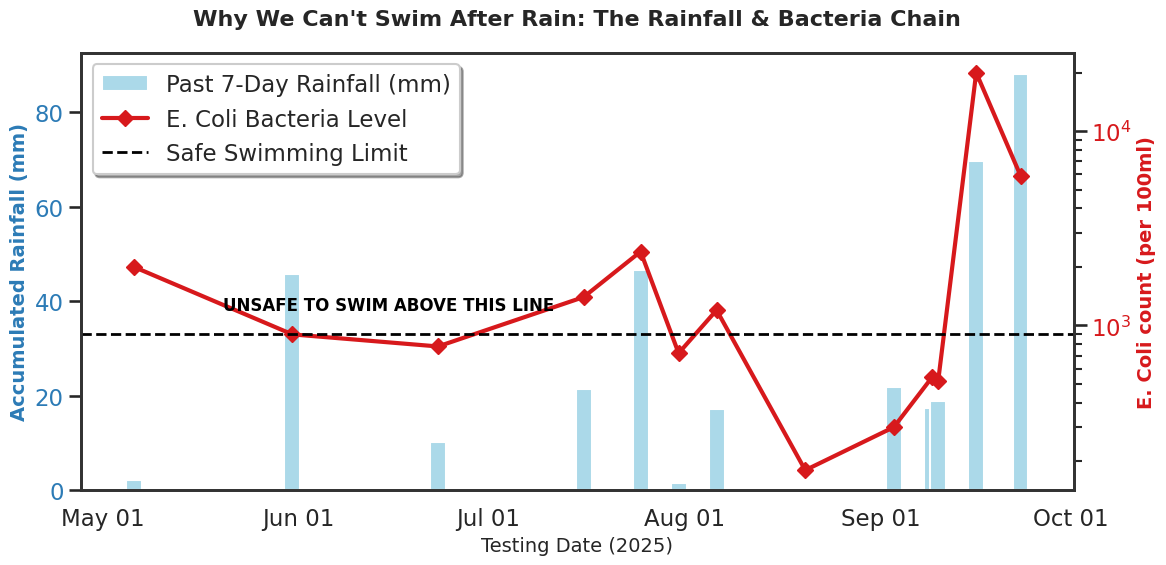

In [ ]:
# 1. Load clean data
df = pd.read_csv('all_sites.csv')

# Ensure the date column is in datetime format
df['Date_obj'] = pd.to_datetime(df['Date_obj'])

# Extract data for the key recreational area (Knaresborough Lido) and sort by time
lido_data = df[df['Site_mapped'] == 'Knaresborough Lido'].copy()
lido_data = lido_data.sort_values('Date_obj')

# Set plot style
sns.set_theme(style="white", context="talk")

# Plot 1: Pollution Source Tracker
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the line charts for Hubac and Rubac
ax.plot(lido_data['Date_obj'], lido_data['Hubac_numeric'], marker='o', markersize=8, color='#d9534f', linewidth=3, label='Human Sewage Marker (Hubac)')
ax.plot(lido_data['Date_obj'], lido_data['Rubac_numeric'], marker='s', markersize=8, color='#5cb85c', linewidth=3, label='Farm Animal Marker (Rubac)')

ax.set_title("What's in the Water? Tracking Fecal Pollution Sources at Knaresborough Lido", fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel("Pollution DNA Level (log scale)", fontsize=14)
ax.set_xlabel("Testing Date (2025)", fontsize=14)

# Format X-axis dates to be easily readable
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(loc='upper left', frameon=True, shadow=True)

# Highlight the heavy rain pollution spike in September
ax.axvspan(pd.to_datetime('2025-09-08'), pd.to_datetime('2025-09-25'), color='red', alpha=0.1)
ax.text(pd.to_datetime('2025-09-16'), 1, 'Sewage & Farm Runoff \nSpike after Heavy Rain', color='red', fontsize=12, ha='center')

# Add borders to make it look like a dashboard card
for spine in ax.spines.values():
    spine.set_linewidth(2)
    spine.set_color('#333333')

plt.tight_layout()
plt.savefig('pollution_sources_lido_final.png', dpi=300, bbox_inches='tight')
plt.show()


# Chart 2: The Chain Reaction of Rain and E. Coli
fig, ax1 = plt.subplots(figsize=(12, 6))

# Left Y-axis: Plot rainfall bar chart (light blue)
color_rain = '#abd9e9'
ax1.bar(lido_data['Date_obj'], lido_data['Rainfall.7_day_sum_mm'], width=2.5, color=color_rain, label='Past 7-Day Rainfall (mm)')
ax1.set_xlabel("Testing Date (2025)", fontsize=14)
ax1.set_ylabel("Accumulated Rainfall (mm)", color='#2c7bb6', fontsize=14, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#2c7bb6')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

# Create a second Y-axis on the right: Plot E. Coli levels (dark red)
ax2 = ax1.twinx()
color_ecoli = '#d7191c'
# Note: The E. Coli data column here is 'e_coli_raw' because we kept the raw data from the bacteria table during the merge
ax2.plot(lido_data['Date_obj'], lido_data['e_coli_raw'], marker='D', markersize=8, color=color_ecoli, linewidth=3, label='E. Coli Bacteria Level')
ax2.set_ylabel("E. Coli count (per 100ml)", color=color_ecoli, fontsize=14, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_ecoli)

# Add a black safety threshold line for swimming (900)
safe_limit = 900
ax2.axhline(y=safe_limit, color='black', linestyle='--', linewidth=2, label='Safe Swimming Limit')
ax2.text(pd.to_datetime('2025-05-20'), safe_limit + 300, 'UNSAFE TO SWIM ABOVE THIS LINE', color='black', fontsize=12, fontweight='bold')

# Set the right Y-axis to a logarithmic scale (Log Scale)
# Otherwise, the spike of 20,000 during heavy rain will flatten the earlier fluctuations
ax2.set_yscale('log')

plt.title("Why We Can't Swim After Rain: The Rainfall & Bacteria Chain", fontsize=16, fontweight='bold', pad=20)

# Combine the legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left', frameon=True, shadow=True)

# Unify the border thickness
for spine in ax1.spines.values():
    spine.set_linewidth(2)
    spine.set_color('#333333')
for spine in ax2.spines.values():
    spine.set_linewidth(2)
    spine.set_color('#333333')

plt.tight_layout()
plt.savefig('rain_ecoli_chain_lido_final.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Add Lattitude and Longitude Data for the data collection points
data = {
    'Site': ['Knaresborough Lido', 'Scotton Mill', 'Hampsthwaite', 'Summerbridge', 'Pateley Bridge'],
    'Lat': [53.996, 54.024, 54.030, 54.059, 54.089],
    'Lon': [-1.455, -1.520, -1.608, -1.695, -1.762],

    'Human_Sewage_Level': [5.1, 4.8, 3.5, 4.2, 2.8],  # Hubac
    'Farm_Runoff_Level': [3.3, 4.1, 4.5, 4.7, 3.1]    # Rubac
}
df = pd.DataFrame(data)


# Set Knaresborough Lido as the center，using OpenStreetMap as the basemap
m = folium.Map(location=[54.040, -1.600], zoom_start=11, tiles='OpenStreetMap')

# Add a title to the map
title_html = '''
    <h3 align="center" style="font-size:20px; font-weight:bold; color:#c9302c; margin-top:10px;">
         River Nidd Water Quality & Pollution Sources
    </h3>
'''
m.get_root().html.add_child(folium.Element(title_html))

# Add information to the map
for idx, row in df.iterrows():
    # Use red and orange to express levels of
    if row['Human_Sewage_Level'] > 4.5 or row['Farm_Runoff_Level'] > 4.5:
        marker_color = 'red'
        status = "<span style='color:red; font-weight:bold;'>High Risk (Do Not Swim)</span>"
    else:
        marker_color = 'orange'
        status = "<span style='color:orange; font-weight:bold;'>Moderate Risk</span>"

    # Add information to display for user on pop-up card
    popup_content = f"""
    <div style="width:200px; font-family:Arial;">
        <h4 style="margin-bottom:5px; color:#333;">{row['Site']}</h4>
        <hr style="margin:5px 0;">
        <b>Current Status:</b> {status}<br><br>
        <b> Pollution Sources:</b><br>
        Human Sewage: <b>{row['Human_Sewage_Level']}</b><br>
        Farm Animal Runoff: <b>{row['Farm_Runoff_Level']}</b><br>
        <hr style="margin:5px 0;">
        <i style="font-size:11px; color:#666;">Data reflects elevated bacteria levels following recent rainfall.</i>
    </div>
    """

    # add pop-up when hovering over point
    folium.CircleMarker(
        location=[row['Lat'], row['Lon']],
        radius=12,
        popup=folium.Popup(popup_content, max_width=250),
        color=marker_color,
        fill=True,
        fill_color=marker_color,
        fill_opacity=0.7,
        tooltip=f"Click to see water quality at {row['Site']}"
    ).add_to(m)

# save file
m.save('tourist_pollution_map.html')
print("successful! open tourist_pollution_map.html ")

successful! open tourist_pollution_map.html 


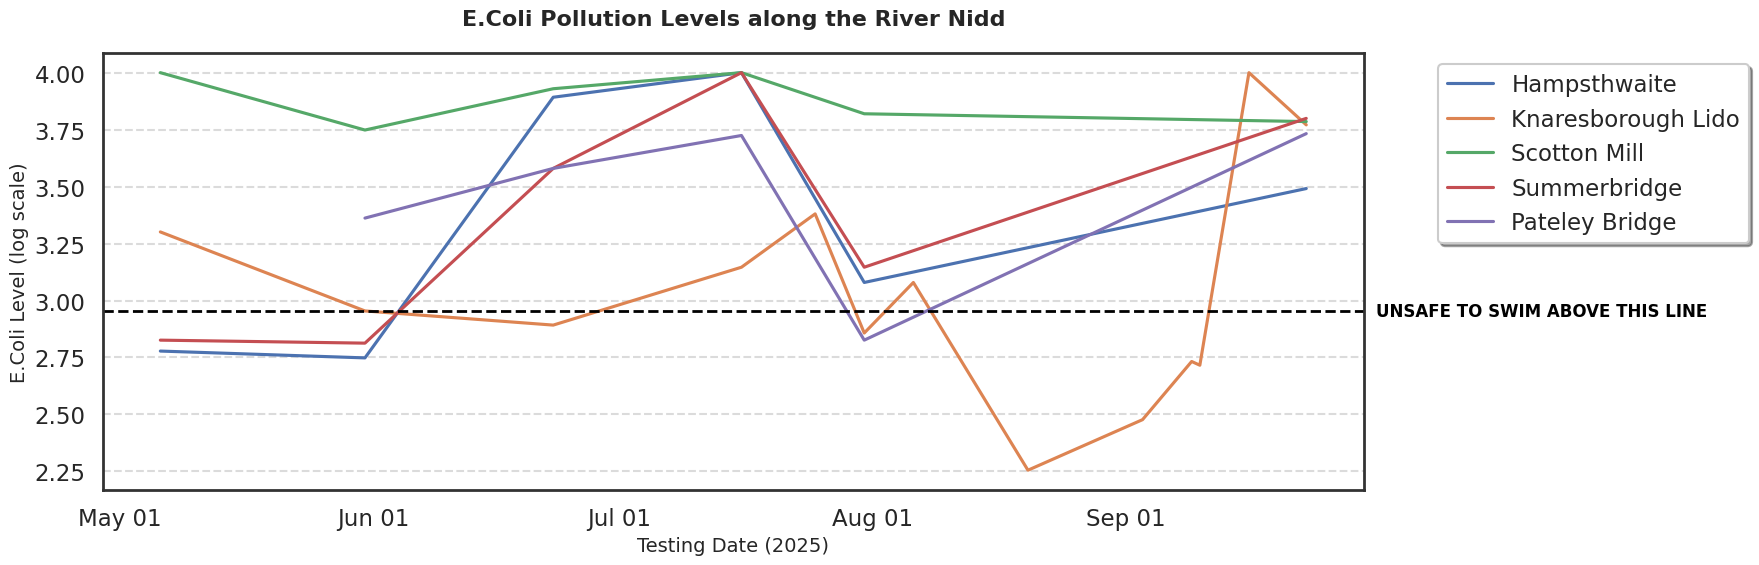

In [ ]:
# Read data
all_sites = pd.read_csv('all_sites.csv')

# Ensure the date column is in datetime format
all_sites['Date_obj'] = pd.to_datetime(all_sites['Date_obj'])

# Set chart style to have a white background and larger font to match other visualisations made in this project
sns.set_theme(style="white", context="talk")

# Create Plot
fig, ax = plt.subplots(figsize=(18, 6))

ax = sns.lineplot(data=all_sites, x="Date_obj", y="log_e_coli_capped", hue="site")

ax.set_title("E.Coli Pollution Levels along the River Nidd", fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel("E.Coli Level (log scale)", fontsize=14)
ax.set_xlabel("Testing Date (2025)", fontsize=14)

# Format X-axis dates to be easily readable
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(bbox_to_anchor = (1.05,1), loc='upper left', frameon=True, shadow=True)

# Add a black safety threshold line for swimming (900)
safe_limit = 2.954
ax.axhline(y=safe_limit, color='black', linestyle='--', linewidth=2, label='Safe Swimming Limit')
ax.text(1.01, safe_limit, 'UNSAFE TO SWIM ABOVE THIS LINE', transform=ax.get_yaxis_transform(), va='center', ha='left', fontsize=12, fontweight='bold', color='black')

# Add borders to make it look like a dashboard card
for spine in ax.spines.values():
    spine.set_linewidth(2)
    spine.set_color('#333333')

plt.tight_layout()
plt.savefig('pollution_sources_lido_final.png', dpi=300, bbox_inches='tight')
plt.show()

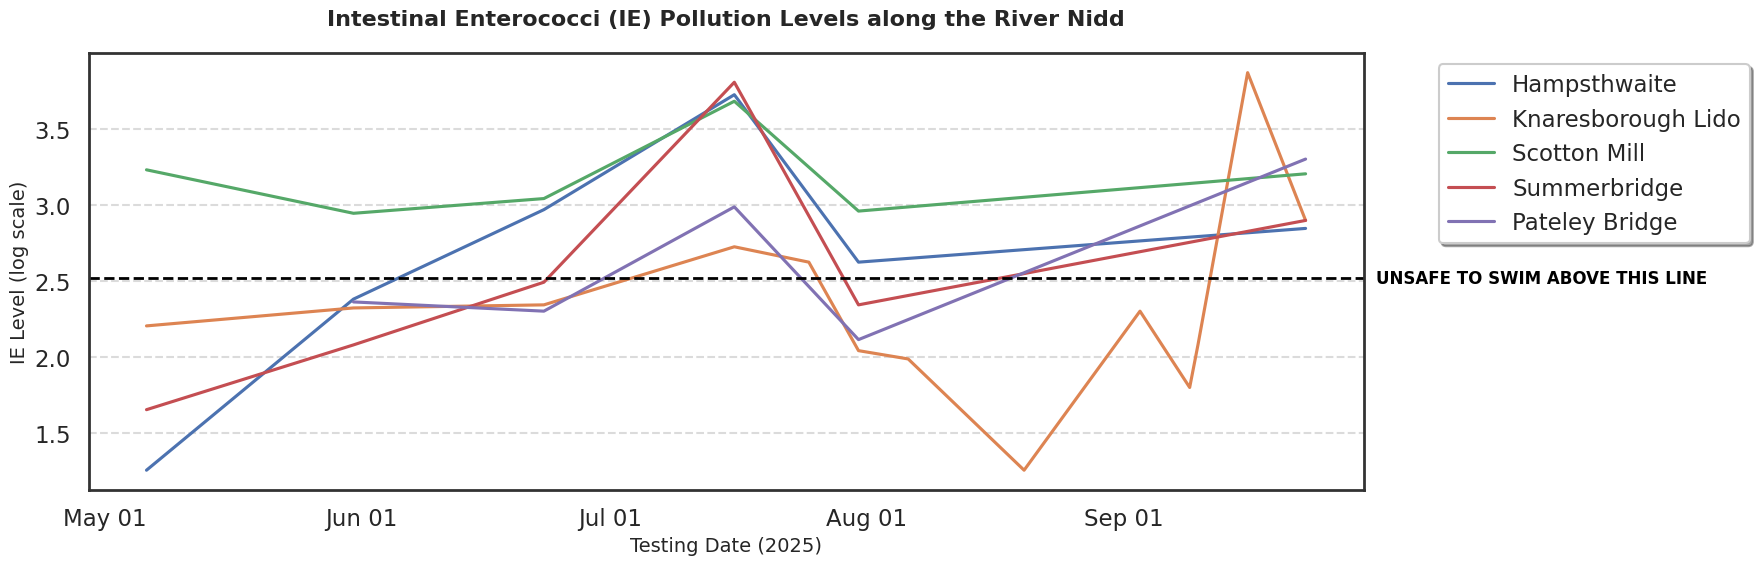

In [ ]:
# Ensure the date column is in datetime format
all_sites['Date_obj'] = pd.to_datetime(all_sites['Date_obj'])

# Set chart style to have a white background and larger font to match other visualisations made in this project
sns.set_theme(style="white", context="talk")

# Create Plot
fig, ax = plt.subplots(figsize=(18, 6))

ax = sns.lineplot(data=all_sites, x="Date_obj", y="log_ie_capped", hue="site")

ax.set_title("Intestinal Enterococci (IE) Pollution Levels along the River Nidd", fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel("IE Level (log scale)", fontsize=14)
ax.set_xlabel("Testing Date (2025)", fontsize=14)

# Format X-axis dates to be easily readable
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(bbox_to_anchor = (1.05,1), loc='upper left', frameon=True, shadow=True)

# Add a black safety threshold line for swimming (900)
safe_limit = 2.52
ax.axhline(y=safe_limit, color='black', linestyle='--', linewidth=2, label='Safe Swimming Limit')
ax.text(1.01, safe_limit, 'UNSAFE TO SWIM ABOVE THIS LINE', transform=ax.get_yaxis_transform(), va='center', ha='left', fontsize=12, fontweight='bold', color='black')

# Add borders to make it look like a dashboard card
for spine in ax.spines.values():
    spine.set_linewidth(2)
    spine.set_color('#333333')

plt.tight_layout()
plt.savefig('pollution_sources_lido_final.png', dpi=300, bbox_inches='tight')
plt.show()